# Simulation Log Analysis Report

Use this notebook to sanity-check a simulation run. Update `LOGS_DIR` below if your logs live elsewhere.


## 0. Setup

This section imports the required libraries (`networkx`, `numpy`) and identifies the log files to analyse.


In [1]:
import json
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import pandas as pd
import matplotlib.pyplot as plt

import networkx as nx
import numpy as np

LOGS_DIR = Path("results/20251024/baseline-honest-no-drop-small-degree-20251024-075646")
ALLOWED_SUFFIXES = {".log", ".jsonl", ".txt"}

def parse_timestamp(value: Optional[str]) -> Optional[datetime]:
    if not value or not isinstance(value, str):
        return None
    try:
        if value.endswith("Z"):
            value = value[:-1] + "+00:00"
        return datetime.fromisoformat(value)
    except ValueError:
        return None

def find_log_files(root: Path, allowed_suffixes: Iterable[str]) -> List[Path]:
    root = root.expanduser().resolve()
    if not root.exists():
        print(f"[warn] log directory {root} does not exist.")
        return []
    suffixes = {suffix.lower() for suffix in allowed_suffixes}
    files = sorted(
        p for p in root.rglob("*")
        if p.is_file() and (not suffixes or p.suffix.lower() in suffixes)
    )
    if not files:
        print(f"[warn] no log files with suffixes {sorted(suffixes)} found under {root}.")
    return files

def percentile(values: Sequence[float], pct: float) -> Optional[float]:
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return None
    return float(np.percentile(arr, pct))

LOG_FILES = find_log_files(LOGS_DIR, ALLOWED_SUFFIXES)
print(f"Discovered {len(LOG_FILES)} candidate log files under {LOGS_DIR.resolve()}")


Discovered 1000 candidate log files under /home/igor/repos/committee-analysis/results/20251024/baseline-honest-no-drop-small-degree-20251024-075646


In [2]:
def load_structured_logs(paths: Sequence[Path]) -> List[Dict]:
    records: List[Dict] = []
    skipped = 0
    for path in paths:
        with path.open("r", encoding="utf-8") as handle:
            for line_no, raw in enumerate(handle, 1):
                line = raw.strip()
                if not line:
                    continue
                try:
                    payload = json.loads(line)
                except json.JSONDecodeError:
                    skipped += 1
                    continue
                payload["_file"] = str(path)
                payload["_line"] = line_no
                payload["_timestamp"] = parse_timestamp(payload.get("timestamp") or payload.get("ts"))
                records.append(payload)
    print(f"Loaded {len(records)} structured log lines (skipped {skipped} non-JSON lines)")
    return records

records = load_structured_logs(LOG_FILES)


Loaded 371602 structured log lines (skipped 41000 non-JSON lines)


## 1. Network Graph Checks

Build an undirected graph from neighbour events and report degree statistics and connected components.


In [3]:
def build_network_graph(records: Sequence[Dict]) -> nx.Graph:
    graph = nx.Graph()
    for rec in records:
        node_id = rec.get("node_id")
        if isinstance(node_id, str):
            graph.add_node(node_id)
        msg = rec.get("msg")
        if msg == "Final neighbor list":
            neighbors = rec.get("neighbors") or []
            for neighbor in neighbors:
                if isinstance(neighbor, str) and node_id and neighbor and node_id != neighbor:
                    graph.add_edge(node_id, neighbor)
        elif msg == "Successfully added neighbor":
            peer_id = rec.get("peer_id")
            if isinstance(node_id, str) and isinstance(peer_id, str) and node_id != peer_id:
                graph.add_edge(node_id, peer_id)
    return graph

graph = build_network_graph(records)
print(f"Nodes discovered: {graph.number_of_nodes()}")
print(f"Inferred undirected edges: {graph.number_of_edges()}")

if graph.number_of_nodes():
    degree_values = np.asarray([deg for _, deg in graph.degree()], dtype=int)
    if degree_values.size:
        summary = {
            "min": int(degree_values.min()),
            "max": int(degree_values.max()),
            "mean": float(np.mean(degree_values)),
            "median": float(np.median(degree_values)),
            "p95": percentile(degree_values, 95),
        }
        print("Degree summary:", summary)
        top_degree = sorted(graph.degree, key=lambda item: item[1], reverse=True)[:10]
        if top_degree:
            print("Top nodes by degree:")
            for node, degree in top_degree:
                print(f"  {node}: {degree}")
    components = list(nx.connected_components(graph))
    if components:
        sizes = np.asarray([len(component) for component in components], dtype=int)
        sizes_sorted = np.sort(sizes)[::-1]
        print(f"Connected components: {len(components)}")
        print(f"Largest component size: {int(sizes_sorted[0])}")
        print(f"Smallest component size: {int(sizes_sorted[-1])}")
        if len(components) > 1:
            print("Component sizes (top 10):", ", ".join(str(int(s)) for s in sizes_sorted[:10]))
else:
    print("No node information was found in the logs.")


Nodes discovered: 1000
Inferred undirected edges: 5984
Degree summary: {'min': 6, 'max': 23, 'mean': 11.968, 'median': 12.0, 'p95': 16.0}
Top nodes by degree:
  12D3KooWCZy5PbyjzG3FXLynEcYGeuNbWCFJhKVcDaVHV87DXAAe: 23
  12D3KooWPqNseC5E8EP45XCq5yPtNrkhBSnn6y1PVDoUkZw7NkPv: 21
  12D3KooWD7sXQ4CYR1dAZbT43oLSMDSkRvnNiVkgm6uB7epvdn9w: 20
  12D3KooWFK6Cs2sREoXZipZXWAWX4SDjGBZrTmcXzTqNaHE93EpW: 20
  12D3KooWDNmgkfj5mjGAeSC6r8hfvow6ipPWSTC787rb2HLpaP8o: 19
  12D3KooWLoWkFFVpYfTEPdx4ANivzpmxnoFsh73ZVaKbaDVkwwL5: 19
  12D3KooWHodyps8EqpQGUW5aMYuUN4cPHcMk5YpqD8ir7LqprLMC: 19
  12D3KooWPwzLtTr5WAxrgzwUKgPCRT5WdoqM25d3Fgx3QxDBYsWT: 19
  12D3KooWSCrUxxrUr3TA7MndtAfVVMj7riGX2Z7brRjNPxBamHSt: 18
  12D3KooWRn3aPb1nJuXBdZmPxKm6xyJBgEBX1k1hvAda1AFwcRsJ: 18
Connected components: 1
Largest component size: 1000
Smallest component size: 1000


## 2. Protocol Message Statistics

Summarise per-protocol message volumes from `Message counts` log entries.


Protocol: exante
  Nodes reporting: 1000
  Total round samples: 30000
  Avg messages per round: 3.80
  95th percentile messages per round: 27.00
  Avg messages per node: 114.00
  Min/Max messages per node: 60 / 180
  Valid message ratio: 1.000
    sample node 12D3KooWA6yr8fFZmCKWA17qEdB7b1b1bAkpitWdKLnwxbazCFEG totals: [0, 1, 13, 86, 30]
    sample node 12D3KooWLFmMHJ3j9sfpQzJrTLb5jk7xNX4Etz2Deto1Li1YMKtu totals: [0, 1, 11, 96, 42]
    sample node 12D3KooWH56MVmsaq63dAUr3vRSw7QaWcMpUoD7FAYyemScRHjPr totals: [0, 1, 10, 85, 34]
Protocol: exanteMDAG
  Nodes reporting: 1000
  Total round samples: 31000
  Avg messages per round: 11.03
  95th percentile messages per round: 15.00
  Avg messages per node: 341.99
  Min/Max messages per node: 180 / 540
  Valid message ratio: 1.000
    sample node 12D3KooWA6yr8fFZmCKWA17qEdB7b1b1bAkpitWdKLnwxbazCFEG totals: [13, 13, 13, 13, 13]
    sample node 12D3KooWLFmMHJ3j9sfpQzJrTLb5jk7xNX4Etz2Deto1Li1YMKtu totals: [15, 15, 15, 15, 15]
    sample node 12D3Ko

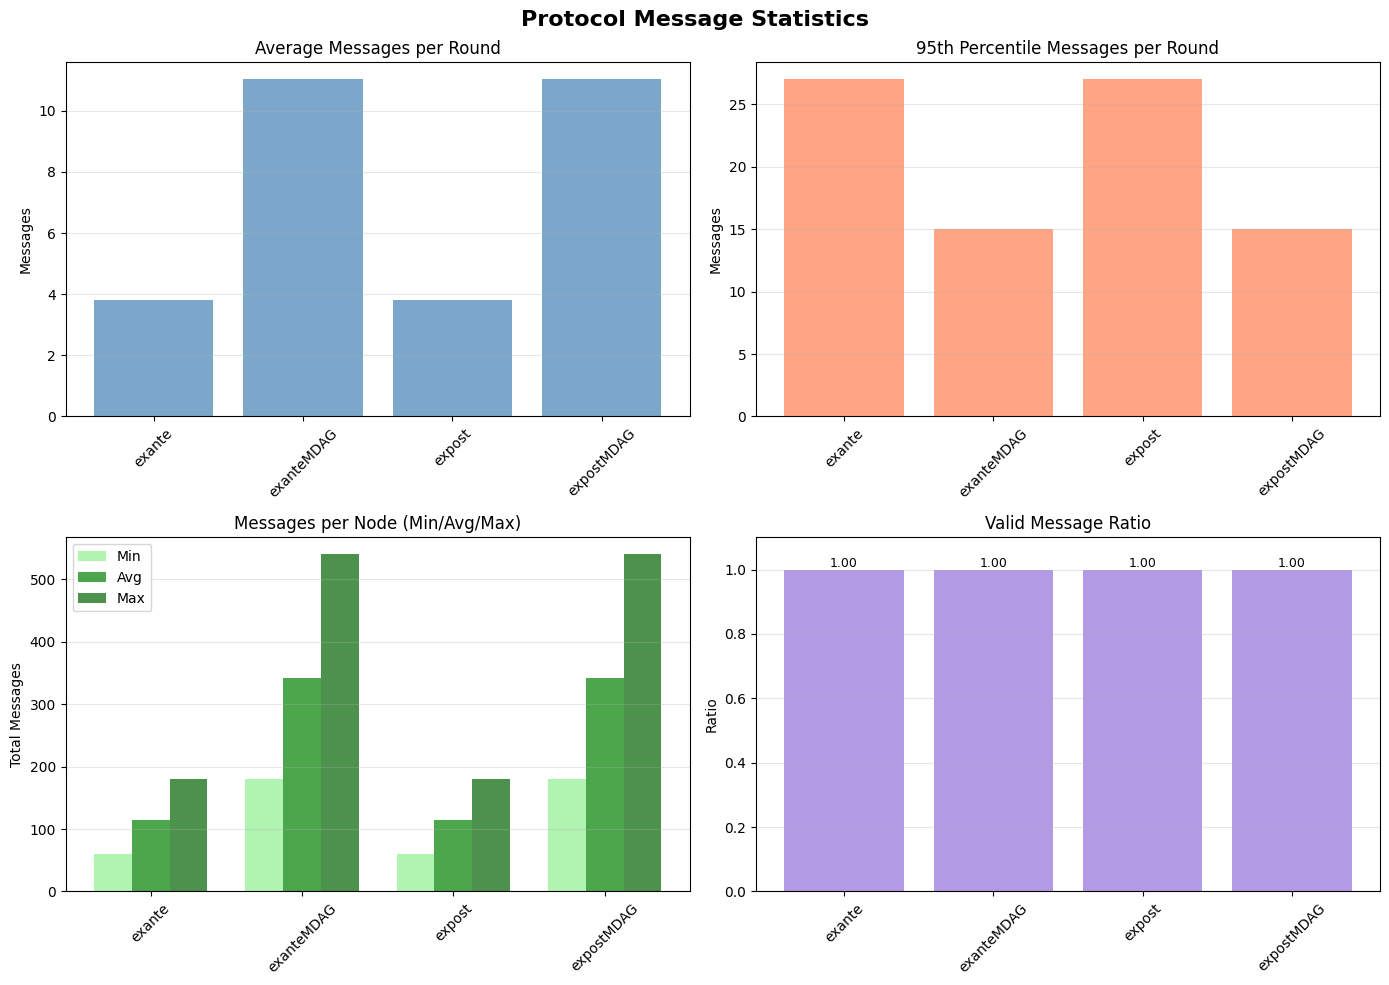

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def extract_message_counts(records: Sequence[Dict]) -> Dict[str, List[Dict]]:
    buckets: Dict[str, List[Dict]] = defaultdict(list)
    for rec in records:
        if rec.get("msg") != "Message counts":
            continue
        protocol = rec.get("logger", "unknown")
        node_id = rec.get("node_id", "unknown")
        totals = rec.get("total_messages") or rec.get("totalMessages") or []
        valids = rec.get("valid_messages") or rec.get("validMessages") or []
        if not isinstance(totals, list):
            continue
        totals_arr = np.asarray(totals, dtype=int)
        valids_arr = np.asarray(valids, dtype=int) if isinstance(valids, list) else np.array([], dtype=int)
        buckets[protocol].append(
            {
                "node": node_id,
                "totals": totals_arr,
                "valids": valids_arr,
                "file": rec.get("_file"),
            }
        )
    return buckets

def flatten(arrays: Iterable[np.ndarray]) -> np.ndarray:
    arrays = list(arrays)
    if not arrays:
        return np.array([], dtype=float)
    return np.concatenate([np.asarray(a, dtype=float) for a in arrays if a.size])

message_counts = extract_message_counts(records)

if not message_counts:
    print("No 'Message counts' entries were found in the logs.")
else:
    # Prepare data for table
    table_data = []
    
    for protocol, entries in sorted(message_counts.items()):
        totals = flatten(entry["totals"] for entry in entries)
        valids = flatten(entry["valids"] for entry in entries)
        totals_per_node = np.asarray([entry["totals"].sum() for entry in entries], dtype=float)
        
        row = {
            "Protocol": protocol,
            "Nodes": len(entries),
            "Total Rounds": int(totals.size),
            "Avg Msg/Round": totals.mean() if totals.size else 0,
            "P95 Msg/Round": percentile(totals, 95) if totals.size else 0,
            "Avg Msg/Node": totals_per_node.mean() if totals_per_node.size else 0,
            "Min Msg/Node": totals_per_node.min() if totals_per_node.size else 0,
            "Max Msg/Node": totals_per_node.max() if totals_per_node.size else 0,
            "Valid Ratio": float(valids.sum() / totals.sum()) if totals.size and valids.size and totals.sum() else float("nan")
        }
        table_data.append(row)
        
        print(f"Protocol: {protocol}")
        print(f"  Nodes reporting: {len(entries)}")
        print(f"  Total round samples: {int(totals.size)}")
        if totals.size:
            print(f"  Avg messages per round: {totals.mean():.2f}")
            p95_total = percentile(totals, 95)
            if p95_total is not None:
                print(f"  95th percentile messages per round: {p95_total:.2f}")
        if totals_per_node.size:
            print(f"  Avg messages per node: {totals_per_node.mean():.2f}")
            print(f"  Min/Max messages per node: {totals_per_node.min():.0f} / {totals_per_node.max():.0f}")
        if totals.size and valids.size:
            ratio = float(valids.sum() / totals.sum()) if totals.sum() else float("nan")
            print(f"  Valid message ratio: {ratio:.3f}")
        for entry in entries[:3]:
            preview = entry["totals"][:5]
            print(f"    sample node {entry['node']} totals: {preview.tolist()}")
    
    # Display as DataFrame table
    print("\n" + "="*80)
    print("MESSAGE STATISTICS SUMMARY TABLE")
    print("="*80 + "\n")
    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))
    
    # Create visualizations
    if len(table_data) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Protocol Message Statistics', fontsize=16, fontweight='bold')
        
        protocols = df["Protocol"].tolist()
        
        # Plot 1: Average Messages per Round
        ax1 = axes[0, 0]
        ax1.bar(protocols, df["Avg Msg/Round"], color='steelblue', alpha=0.7)
        ax1.set_ylabel('Messages')
        ax1.set_title('Average Messages per Round')
        ax1.tick_params(axis='x', rotation=45)
        ax1.grid(axis='y', alpha=0.3)
        
        # Plot 2: P95 Messages per Round
        ax2 = axes[0, 1]
        ax2.bar(protocols, df["P95 Msg/Round"], color='coral', alpha=0.7)
        ax2.set_ylabel('Messages')
        ax2.set_title('95th Percentile Messages per Round')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(axis='y', alpha=0.3)
        
        # Plot 3: Messages per Node (Min/Avg/Max)
        ax3 = axes[1, 0]
        x = np.arange(len(protocols))
        width = 0.25
        ax3.bar(x - width, df["Min Msg/Node"], width, label='Min', color='lightgreen', alpha=0.7)
        ax3.bar(x, df["Avg Msg/Node"], width, label='Avg', color='green', alpha=0.7)
        ax3.bar(x + width, df["Max Msg/Node"], width, label='Max', color='darkgreen', alpha=0.7)
        ax3.set_ylabel('Total Messages')
        ax3.set_title('Messages per Node (Min/Avg/Max)')
        ax3.set_xticks(x)
        ax3.set_xticklabels(protocols, rotation=45)
        ax3.legend()
        ax3.grid(axis='y', alpha=0.3)
        
        # Plot 4: Valid Message Ratio
        ax4 = axes[1, 1]
        valid_ratios = [r if not np.isnan(r) else 0 for r in df["Valid Ratio"]]
        bars = ax4.bar(protocols, valid_ratios, color='mediumpurple', alpha=0.7)
        ax4.set_ylabel('Ratio')
        ax4.set_title('Valid Message Ratio')
        ax4.set_ylim(0, 1.1)
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax4.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}',
                        ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()


## 3. Committee Selection Consistency

Check how often each member appears across committee election results.


In [5]:
committee_logs = [rec for rec in records if rec.get("msg") == "Committee elected"]

if not committee_logs:
    print("No committee election logs found.")
else:
    selection_counter = Counter()
    committee_sizes = []
    for rec in committee_logs:
        committee = rec.get("committee") or []
        if isinstance(committee, list):
            committee_sizes.append(len(committee))
            for member in committee:
                member_id = None
                if isinstance(member, dict):
                    member_id = member.get("ID") or member.get("id")
                elif isinstance(member, (list, tuple)) and member:
                    member_id = member[0]
                if member_id:
                    selection_counter[str(member_id)] += 1
    print(f"Committee elections observed: {len(committee_logs)}")
    if committee_sizes:
        sizes = np.asarray(committee_sizes, dtype=float)
        print(f"  Average committee size: {sizes.mean():.2f}")
        print(f"  Committee size range: {int(sizes.min())} - {int(sizes.max())}")
    if selection_counter:
        counts = np.asarray(list(selection_counter.values()), dtype=float)
        print(f"  Unique members selected: {len(selection_counter)}")
        print(f"  Min selections per member: {int(counts.min())}")
        print(f"  Max selections per member: {int(counts.max())}")
        p95 = percentile(counts, 95)
        if p95 is not None:
            print(f"  95th percentile selections: {p95:.2f}")
        print("  Top-selected members:")
        for member_id, count in selection_counter.most_common(10):
            print(f"    {member_id}: {count}")
    else:
        print("  Committee membership data was not available in the logs.")


Committee elections observed: 1000
  Average committee size: 10.00
  Committee size range: 10 - 10
  Unique members selected: 10
  Min selections per member: 1000
  Max selections per member: 1000
  95th percentile selections: 1000.00
  Top-selected members:
    12D3KooWSb7PuxVfCztXwQLnrXDxNCmYXx34P6Biq2353RoAyLRD: 1000
    12D3KooWNEGTpZPKGvJqcpLUp1cRS4kSSfA7r6RZejY3Dmu8s6rY: 1000
    12D3KooWHBe9D3kBbrKPfEppQv1tH9yE8chr21iZmmzEKppDDR3X: 1000
    12D3KooWG6gcTeXdsbpurWT8AjenxvhJBPhzcmoS8T2zuuhCkVwf: 1000
    12D3KooWAVF3SXh3KpebhZfsXH4N3TjskFUQ8fn41MEY6iFPGV6Y: 1000
    12D3KooWK6quv6HPyd4DgVxpcoz5rrkG69tovEA6XwUrazTmB34r: 1000
    12D3KooW9znmQbAiurSfGHn4wi7yEr45gyr4FN6dAR93x1dnS1TE: 1000
    12D3KooWC8biHThAG1mecViWkMFwWuQkMVQ2LS9E66CCipBUS3gB: 1000
    12D3KooWEfP35sQrWz7i8wbb1qpjZDHPwy2JcztEZvjC5uaFRk9M: 1000
    12D3KooWCFxaF4tKytaEoF7HSeNpaqEMK8h4o1QPayjcgBP8Xbn2: 1000


## 3a. Committee Similarity Analysis

Compare committees elected by different nodes using multiple similarity metrics:
- **Set-based metrics**: Jaccard index, Dice coefficient, Overlap coefficient
- **Correlation metrics**: Pearson correlation, Cohen's kappa
- **Consensus analysis**: Global intersection and full consensus detection


Analyzing committee similarity across 1000 nodes...

COMMITTEE COMPARISON SUMMARY
Total nodes: 1000
Total unique members across all committees: 10
Average committee size: 10.00
Committee size range: 10 - 10

Global intersection (members ALL nodes agreed on): 10
  Members: ['12D3KooW9znmQbAiurSfGHn4wi7yEr45gyr4FN6dAR93x1dnS1TE', '12D3KooWAVF3SXh3KpebhZfsXH4N3TjskFUQ8fn41MEY6iFPGV6Y', '12D3KooWC8biHThAG1mecViWkMFwWuQkMVQ2LS9E66CCipBUS3gB', '12D3KooWCFxaF4tKytaEoF7HSeNpaqEMK8h4o1QPayjcgBP8Xbn2', '12D3KooWEfP35sQrWz7i8wbb1qpjZDHPwy2JcztEZvjC5uaFRk9M', '12D3KooWG6gcTeXdsbpurWT8AjenxvhJBPhzcmoS8T2zuuhCkVwf', '12D3KooWHBe9D3kBbrKPfEppQv1tH9yE8chr21iZmmzEKppDDR3X', '12D3KooWK6quv6HPyd4DgVxpcoz5rrkG69tovEA6XwUrazTmB34r', '12D3KooWNEGTpZPKGvJqcpLUp1cRS4kSSfA7r6RZejY3Dmu8s6rY', '12D3KooWSb7PuxVfCztXwQLnrXDxNCmYXx34P6Biq2353RoAyLRD']

Full consensus (all committees identical): True

Pairwise similarity metrics (across 499500 node pairs):
  Average Jaccard index: 1.0000
  Jaccard range: 1.0000 - 1

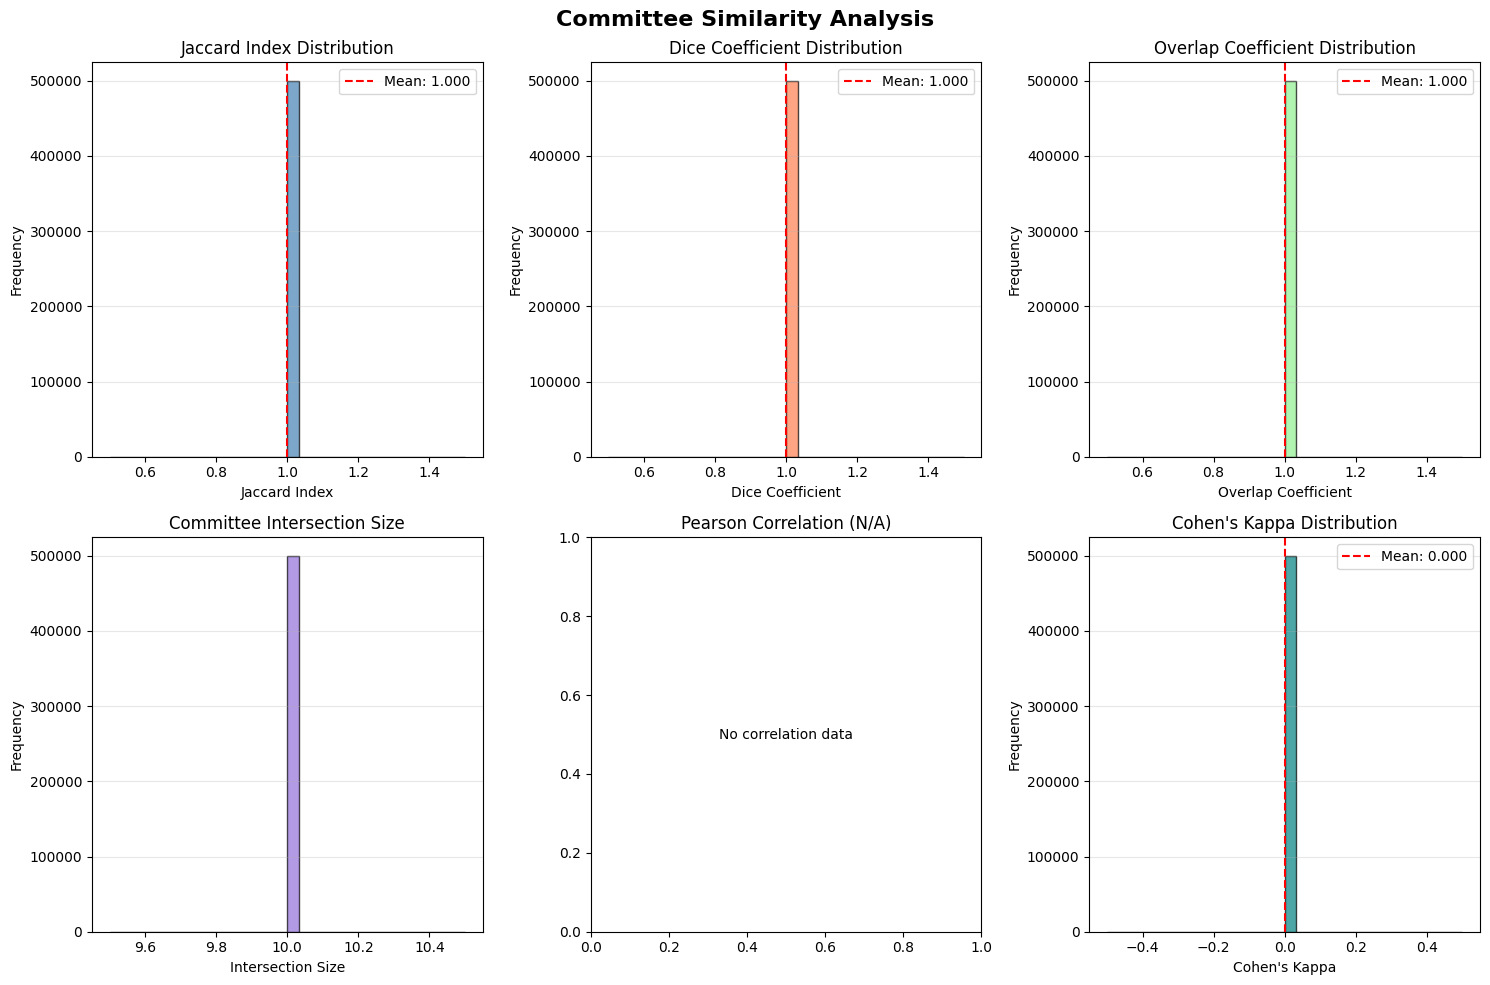

In [6]:
from itertools import combinations
from scipy import stats

def compute_committee_similarity(committees: Dict[str, List[str]]) -> Tuple[pd.DataFrame, Dict]:
    """
    Compare committees elected by different nodes.
    
    Args:
        committees: Dict mapping node_id -> list of member IDs
        
    Returns:
        Tuple of (pairwise_df, summary_dict)
    """
    if not committees:
        return pd.DataFrame(), {}
    
    # Convert to sets for easier computation
    committee_sets = {node: set(members) for node, members in committees.items()}
    node_ids = sorted(committee_sets.keys())
    
    # Compute global intersection (members all nodes agreed on)
    if committee_sets:
        global_intersection = set.intersection(*committee_sets.values())
    else:
        global_intersection = set()
    
    # Check for full consensus
    first_committee = next(iter(committee_sets.values()))
    full_consensus = all(comm == first_committee for comm in committee_sets.values())
    
    # Compute pairwise statistics
    pairwise_data = []
    for node_a, node_b in combinations(node_ids, 2):
        set_a = committee_sets[node_a]
        set_b = committee_sets[node_b]
        
        intersection = set_a & set_b
        union = set_a | set_b
        
        intersection_size = len(intersection)
        union_size = len(union)
        size_a = len(set_a)
        size_b = len(set_b)
        
        # Jaccard index
        jaccard = intersection_size / union_size if union_size > 0 else 0.0
        
        # Dice coefficient
        dice = (2 * intersection_size) / (size_a + size_b) if (size_a + size_b) > 0 else 0.0
        
        # Overlap coefficient
        overlap = intersection_size / min(size_a, size_b) if min(size_a, size_b) > 0 else 0.0
        
        pairwise_data.append({
            "Node A": node_a,
            "Node B": node_b,
            "Size A": size_a,
            "Size B": size_b,
            "Intersection": intersection_size,
            "Union": union_size,
            "Jaccard": jaccard,
            "Dice": dice,
            "Overlap": overlap,
            "Common %": (intersection_size / size_a * 100) if size_a > 0 else 0.0,
        })
    
    pairwise_df = pd.DataFrame(pairwise_data)
    
    # Compute correlation metrics if we have enough data
    all_members = set()
    for members in committee_sets.values():
        all_members.update(members)
    all_members = sorted(all_members)
    
    # Create binary membership matrix: rows=nodes, cols=members
    membership_matrix = np.zeros((len(node_ids), len(all_members)), dtype=int)
    for i, node in enumerate(node_ids):
        for j, member in enumerate(all_members):
            if member in committee_sets[node]:
                membership_matrix[i, j] = 1
    
    # Compute pairwise Pearson correlation
    correlations = []
    if len(node_ids) >= 2 and len(all_members) > 0:
        for node_a, node_b in combinations(node_ids, 2):
            idx_a = node_ids.index(node_a)
            idx_b = node_ids.index(node_b)
            vec_a = membership_matrix[idx_a]
            vec_b = membership_matrix[idx_b]
            
            if vec_a.std() > 0 and vec_b.std() > 0:
                corr, _ = stats.pearsonr(vec_a, vec_b)
                correlations.append({
                    "Node A": node_a,
                    "Node B": node_b,
                    "Pearson Corr": corr
                })
    
    correlation_df = pd.DataFrame(correlations) if correlations else pd.DataFrame()
    
    # Compute Cohen's kappa across all pairs
    kappa_scores = []
    if len(node_ids) >= 2:
        for node_a, node_b in combinations(node_ids, 2):
            idx_a = node_ids.index(node_a)
            idx_b = node_ids.index(node_b)
            vec_a = membership_matrix[idx_a]
            vec_b = membership_matrix[idx_b]
            
            # Cohen's kappa
            try:
                # Agreement
                p_o = np.mean(vec_a == vec_b)
                # Expected agreement
                p_yes_a = np.mean(vec_a)
                p_no_a = 1 - p_yes_a
                p_yes_b = np.mean(vec_b)
                p_no_b = 1 - p_yes_b
                p_e = p_yes_a * p_yes_b + p_no_a * p_no_b
                
                kappa = (p_o - p_e) / (1 - p_e) if (1 - p_e) > 0 else 0.0
                kappa_scores.append({
                    "Node A": node_a,
                    "Node B": node_b,
                    "Cohen's Kappa": kappa
                })
            except:
                pass
    
    kappa_df = pd.DataFrame(kappa_scores) if kappa_scores else pd.DataFrame()
    
    # Merge correlation metrics into pairwise_df
    if not correlation_df.empty:
        pairwise_df = pairwise_df.merge(correlation_df, on=["Node A", "Node B"], how="left")
    if not kappa_df.empty:
        pairwise_df = pairwise_df.merge(kappa_df, on=["Node A", "Node B"], how="left")
    
    # Summary statistics
    summary = {
        "total_nodes": len(node_ids),
        "total_unique_members": len(all_members),
        "global_intersection_size": len(global_intersection),
        "global_intersection_members": sorted(global_intersection),
        "full_consensus": full_consensus,
        "avg_committee_size": np.mean([len(c) for c in committee_sets.values()]),
        "min_committee_size": min(len(c) for c in committee_sets.values()) if committee_sets else 0,
        "max_committee_size": max(len(c) for c in committee_sets.values()) if committee_sets else 0,
    }
    
    if not pairwise_df.empty:
        summary["avg_jaccard"] = pairwise_df["Jaccard"].mean()
        summary["min_jaccard"] = pairwise_df["Jaccard"].min()
        summary["max_jaccard"] = pairwise_df["Jaccard"].max()
        summary["avg_dice"] = pairwise_df["Dice"].mean()
        summary["avg_overlap"] = pairwise_df["Overlap"].mean()
        if "Pearson Corr" in pairwise_df.columns:
            summary["avg_pearson_corr"] = pairwise_df["Pearson Corr"].mean()
        if "Cohen's Kappa" in pairwise_df.columns:
            summary["avg_cohens_kappa"] = pairwise_df["Cohen's Kappa"].mean()
    
    return pairwise_df, summary


# Extract committees from logs
def extract_committees_by_node(records: Sequence[Dict]) -> Dict[str, List[str]]:
    """
    Extract the most recent committee election for each node.
    Returns dict: node_id -> list of member IDs
    """
    # Group by node, keep most recent
    node_committees = {}
    for rec in records:
        if rec.get("msg") == "Committee elected":
            node_id = rec.get("node_id")
            committee = rec.get("committee") or []
            if not node_id or not isinstance(committee, list):
                continue
            
            # Extract member IDs
            member_ids = []
            for member in committee:
                member_id = None
                if isinstance(member, dict):
                    member_id = member.get("ID") or member.get("id")
                elif isinstance(member, (list, tuple)) and member:
                    member_id = member[0]
                elif isinstance(member, str):
                    member_id = member
                
                if member_id:
                    member_ids.append(str(member_id))
            
            # Store or update (keeps last election per node)
            node_committees[str(node_id)] = member_ids
    
    return node_committees


# Run the analysis
node_committees = extract_committees_by_node(records)

if not node_committees:
    print("No committee data available for comparison.")
elif len(node_committees) < 2:
    print(f"Only {len(node_committees)} node(s) have committee data. Need at least 2 for comparison.")
else:
    print(f"\nAnalyzing committee similarity across {len(node_committees)} nodes...\n")
    
    pairwise_df, summary = compute_committee_similarity(node_committees)
    
    # Print summary
    print("="*80)
    print("COMMITTEE COMPARISON SUMMARY")
    print("="*80)
    print(f"Total nodes: {summary['total_nodes']}")
    print(f"Total unique members across all committees: {summary['total_unique_members']}")
    print(f"Average committee size: {summary['avg_committee_size']:.2f}")
    print(f"Committee size range: {int(summary['min_committee_size'])} - {int(summary['max_committee_size'])}")
    print(f"\nGlobal intersection (members ALL nodes agreed on): {summary['global_intersection_size']}")
    if summary['global_intersection_members']:
        print(f"  Members: {summary['global_intersection_members'][:10]}")
        if len(summary['global_intersection_members']) > 10:
            print(f"  ... and {len(summary['global_intersection_members']) - 10} more")
    print(f"\nFull consensus (all committees identical): {summary['full_consensus']}")
    
    if not pairwise_df.empty:
        print(f"\nPairwise similarity metrics (across {len(pairwise_df)} node pairs):")
        print(f"  Average Jaccard index: {summary['avg_jaccard']:.4f}")
        print(f"  Jaccard range: {summary['min_jaccard']:.4f} - {summary['max_jaccard']:.4f}")
        print(f"  Average Dice coefficient: {summary['avg_dice']:.4f}")
        print(f"  Average Overlap coefficient: {summary['avg_overlap']:.4f}")
        if 'avg_pearson_corr' in summary:
            print(f"  Average Pearson correlation: {summary['avg_pearson_corr']:.4f}")
        if 'avg_cohens_kappa' in summary:
            print(f"  Average Cohen's kappa: {summary['avg_cohens_kappa']:.4f}")
    
    # Display pairwise comparison table
    if not pairwise_df.empty:
        print("\n" + "="*80)
        print("PAIRWISE COMMITTEE COMPARISON")
        print("="*80 + "\n")
        
        # Show top 20 most similar pairs
        top_pairs = pairwise_df.nlargest(20, "Jaccard")
        print("Top 20 most similar node pairs (by Jaccard index):")
        print(top_pairs.to_string(index=False))
        
        # Show statistics
        print("\n" + "="*80)
        print("SIMILARITY DISTRIBUTION STATISTICS")
        print("="*80 + "\n")
        stats_df = pairwise_df[["Jaccard", "Dice", "Overlap"]].describe()
        if "Pearson Corr" in pairwise_df.columns:
            stats_df = pd.concat([stats_df, pairwise_df[["Pearson Corr"]].describe()], axis=1)
        if "Cohen's Kappa" in pairwise_df.columns:
            stats_df = pd.concat([stats_df, pairwise_df[["Cohen's Kappa"]].describe()], axis=1)
        print(stats_df.to_string())
        
        # Visualize distributions
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle('Committee Similarity Analysis', fontsize=16, fontweight='bold')
        
        # Plot 1: Jaccard distribution
        ax1 = axes[0, 0]
        ax1.hist(pairwise_df["Jaccard"], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        ax1.set_xlabel('Jaccard Index')
        ax1.set_ylabel('Frequency')
        ax1.set_title('Jaccard Index Distribution')
        ax1.axvline(summary['avg_jaccard'], color='red', linestyle='--', label=f'Mean: {summary["avg_jaccard"]:.3f}')
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)
        
        # Plot 2: Dice distribution
        ax2 = axes[0, 1]
        ax2.hist(pairwise_df["Dice"], bins=30, color='coral', alpha=0.7, edgecolor='black')
        ax2.set_xlabel('Dice Coefficient')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Dice Coefficient Distribution')
        ax2.axvline(summary['avg_dice'], color='red', linestyle='--', label=f'Mean: {summary["avg_dice"]:.3f}')
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)
        
        # Plot 3: Overlap distribution
        ax3 = axes[0, 2]
        ax3.hist(pairwise_df["Overlap"], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
        ax3.set_xlabel('Overlap Coefficient')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Overlap Coefficient Distribution')
        ax3.axvline(summary['avg_overlap'], color='red', linestyle='--', label=f'Mean: {summary["avg_overlap"]:.3f}')
        ax3.legend()
        ax3.grid(axis='y', alpha=0.3)
        
        # Plot 4: Intersection size distribution
        ax4 = axes[1, 0]
        ax4.hist(pairwise_df["Intersection"], bins=30, color='mediumpurple', alpha=0.7, edgecolor='black')
        ax4.set_xlabel('Intersection Size')
        ax4.set_ylabel('Frequency')
        ax4.set_title('Committee Intersection Size')
        ax4.grid(axis='y', alpha=0.3)
        
        # Plot 5: Pearson correlation (if available)
        ax5 = axes[1, 1]
        if "Pearson Corr" in pairwise_df.columns:
            ax5.hist(pairwise_df["Pearson Corr"].dropna(), bins=30, color='orange', alpha=0.7, edgecolor='black')
            ax5.set_xlabel('Pearson Correlation')
            ax5.set_ylabel('Frequency')
            ax5.set_title('Pearson Correlation Distribution')
            if 'avg_pearson_corr' in summary:
                ax5.axvline(summary['avg_pearson_corr'], color='red', linestyle='--', 
                           label=f'Mean: {summary["avg_pearson_corr"]:.3f}')
                ax5.legend()
            ax5.grid(axis='y', alpha=0.3)
        else:
            ax5.text(0.5, 0.5, 'No correlation data', ha='center', va='center', transform=ax5.transAxes)
            ax5.set_title('Pearson Correlation (N/A)')
        
        # Plot 6: Cohen's Kappa (if available)
        ax6 = axes[1, 2]
        if "Cohen's Kappa" in pairwise_df.columns:
            ax6.hist(pairwise_df["Cohen's Kappa"].dropna(), bins=30, color='teal', alpha=0.7, edgecolor='black')
            ax6.set_xlabel("Cohen's Kappa")
            ax6.set_ylabel('Frequency')
            ax6.set_title("Cohen's Kappa Distribution")
            if 'avg_cohens_kappa' in summary:
                ax6.axvline(summary['avg_cohens_kappa'], color='red', linestyle='--', 
                           label=f'Mean: {summary["avg_cohens_kappa"]:.3f}')
                ax6.legend()
            ax6.grid(axis='y', alpha=0.3)
        else:
            ax6.text(0.5, 0.5, 'No kappa data', ha='center', va='center', transform=ax6.transAxes)
            ax6.set_title("Cohen's Kappa (N/A)")
        
        plt.tight_layout()
        plt.show()


## 4. Error & Warning Audit

Surface warning and error log entries to highlight potential issues that may need manual inspection.


In [7]:
def summarize_alerts(records: Sequence[Dict]) -> List[Dict]:
    alerts: List[Dict] = []
    for rec in records:
        level = str(rec.get("level", "")).upper()
        if level in {"ERROR", "WARN", "WARNING"}:
            alerts.append(rec)
    return alerts

alerts = summarize_alerts(records)
if not alerts:
    print("No warnings or errors detected in the logs.")
else:
    by_node = Counter()
    for entry in alerts:
        node = entry.get("node_id", "global")
        level = str(entry.get("level", "")).upper()
        if level == "WARNING":
            level = "WARN"
        by_node[(node, level)] += 1
    print("Warnings/errors by node:")
    for (node, level), count in sorted(by_node.items(), key=lambda kv: (-kv[1], kv[0][0], kv[0][1])):
        print(f"  {level:<5} | {node}: {count}")
    print("Recent alert examples:")
    for entry in alerts[:5]:
        ts = entry.get("_timestamp") or entry.get("timestamp")
        ts_str = ts.isoformat() if isinstance(ts, datetime) else str(ts)
        print(f"  [{entry.get('level')}] {ts_str} {entry.get('node_id', 'global')}: {entry.get('msg')}")


Warnings/errors by node:
  WARN  | global: 985
Recent alert examples:
  [WARN] 2025-10-24T07:56:56.952000+00:00 global: DHT advertisement attempt failed
  [WARN] 2025-10-24T07:56:56.820000+00:00 global: DHT advertisement attempt failed
  [WARN] 2025-10-24T07:56:57.745000+00:00 global: DHT advertisement attempt failed
  [WARN] 2025-10-24T07:57:00.847000+00:00 global: DHT advertisement attempt failed
  [WARN] 2025-10-24T07:56:57.744000+00:00 global: DHT advertisement attempt failed


## Batch Analysis: Process Multiple Simulations

Run the complete analysis pipeline on multiple simulation directories.

In [ ]:
import tarfile
import shutil

def process_simulation(sim_path: Path, sim_name: str):
    """
    Run all analysis sections for a single simulation.
    
    Args:
        sim_path: Path to the simulation directory containing logs
        sim_name: Display name for the simulation
    """
    print("\n" + "="*100)
    print(f"SIMULATION: {sim_name}")
    print("="*100 + "\n")
    
    # Find log files in this simulation
    log_files = find_log_files(sim_path, ALLOWED_SUFFIXES)
    
    if not log_files:
        print(f"[SKIP] No log files found in {sim_path}")
        return
    
    print(f"Found {len(log_files)} log files")
    
    # Load logs
    sim_records = load_structured_logs(log_files)
    
    if not sim_records:
        print(f"[SKIP] No valid log records found")
        return
    
    # Section 1: Network Graph Checks
    print("\n" + "-"*80)
    print("SECTION 1: Network Graph Analysis")
    print("-"*80 + "\n")
    
    sim_graph = build_network_graph(sim_records)
    print(f"Nodes discovered: {sim_graph.number_of_nodes()}")
    print(f"Inferred undirected edges: {sim_graph.number_of_edges()}")
    
    if sim_graph.number_of_nodes():
        degree_values = np.asarray([deg for _, deg in sim_graph.degree()], dtype=int)
        if degree_values.size:
            summary = {
                "min": int(degree_values.min()),
                "max": int(degree_values.max()),
                "mean": float(np.mean(degree_values)),
                "median": float(np.median(degree_values)),
                "p95": percentile(degree_values, 95),
            }
            print("Degree summary:", summary)
            top_degree = sorted(sim_graph.degree, key=lambda item: item[1], reverse=True)[:10]
            if top_degree:
                print("Top nodes by degree:")
                for node, degree in top_degree[:5]:  # Show top 5
                    print(f"  {node}: {degree}")
        components = list(nx.connected_components(sim_graph))
        if components:
            sizes = np.asarray([len(component) for component in components], dtype=int)
            sizes_sorted = np.sort(sizes)[::-1]
            print(f"Connected components: {len(components)}")
            print(f"Largest component size: {int(sizes_sorted[0])}")
            print(f"Smallest component size: {int(sizes_sorted[-1])}")
    else:
        print("No node information was found in the logs.")
    
    # Section 2: Protocol Message Statistics
    print("\n" + "-"*80)
    print("SECTION 2: Protocol Message Statistics")
    print("-"*80 + "\n")
    
    sim_message_counts = extract_message_counts(sim_records)
    
    if not sim_message_counts:
        print("No 'Message counts' entries were found in the logs.")
    else:
        table_data = []
        
        for protocol, entries in sorted(sim_message_counts.items()):
            totals = flatten(entry["totals"] for entry in entries)
            valids = flatten(entry["valids"] for entry in entries)
            totals_per_node = np.asarray([entry["totals"].sum() for entry in entries], dtype=float)
            
            row = {
                "Protocol": protocol,
                "Nodes": len(entries),
                "Total Rounds": int(totals.size),
                "Avg Msg/Round": totals.mean() if totals.size else 0,
                "P95 Msg/Round": percentile(totals, 95) if totals.size else 0,
                "Avg Msg/Node": totals_per_node.mean() if totals_per_node.size else 0,
                "Min Msg/Node": totals_per_node.min() if totals_per_node.size else 0,
                "Max Msg/Node": totals_per_node.max() if totals_per_node.size else 0,
                "Valid Ratio": float(valids.sum() / totals.sum()) if totals.size and valids.size and totals.sum() else float("nan")
            }
            table_data.append(row)
            
            print(f"Protocol: {protocol}")
            print(f"  Nodes reporting: {len(entries)}")
            print(f"  Total round samples: {int(totals.size)}")
            if totals.size:
                print(f"  Avg messages per round: {totals.mean():.2f}")
                p95_total = percentile(totals, 95)
                if p95_total is not None:
                    print(f"  95th percentile messages per round: {p95_total:.2f}")
            if totals_per_node.size:
                print(f"  Avg messages per node: {totals_per_node.mean():.2f}")
                print(f"  Min/Max messages per node: {totals_per_node.min():.0f} / {totals_per_node.max():.0f}")
            if totals.size and valids.size:
                ratio = float(valids.sum() / totals.sum()) if totals.sum() else float("nan")
                print(f"  Valid message ratio: {ratio:.3f}")
        
        if table_data:
            df = pd.DataFrame(table_data)
            print("\nMessage Statistics Summary:")
            print(df.to_string(index=False))
    
    # Section 3: Committee Selection Consistency
    print("\n" + "-"*80)
    print("SECTION 3: Committee Selection Consistency")
    print("-"*80 + "\n")
    
    committee_logs = [rec for rec in sim_records if rec.get("msg") == "Committee elected"]
    
    if not committee_logs:
        print("No committee election logs found.")
    else:
        selection_counter = Counter()
        committee_sizes = []
        for rec in committee_logs:
            committee = rec.get("committee") or []
            if isinstance(committee, list):
                committee_sizes.append(len(committee))
                for member in committee:
                    member_id = None
                    if isinstance(member, dict):
                        member_id = member.get("ID") or member.get("id")
                    elif isinstance(member, (list, tuple)) and member:
                        member_id = member[0]
                    if member_id:
                        selection_counter[str(member_id)] += 1
        print(f"Committee elections observed: {len(committee_logs)}")
        if committee_sizes:
            sizes = np.asarray(committee_sizes, dtype=float)
            print(f"  Average committee size: {sizes.mean():.2f}")
            print(f"  Committee size range: {int(sizes.min())} - {int(sizes.max())}")
        if selection_counter:
            counts = np.asarray(list(selection_counter.values()), dtype=float)
            print(f"  Unique members selected: {len(selection_counter)}")
            print(f"  Min selections per member: {int(counts.min())}")
            print(f"  Max selections per member: {int(counts.max())}")
            p95 = percentile(counts, 95)
            if p95 is not None:
                print(f"  95th percentile selections: {p95:.2f}")
            print("  Top-selected members (top 5):")
            for member_id, count in selection_counter.most_common(5):
                print(f"    {member_id}: {count}")
    
    # Section 3a: Committee Similarity Analysis
    print("\n" + "-"*80)
    print("SECTION 3a: Committee Similarity Analysis")
    print("-"*80 + "\n")
    
    sim_node_committees = extract_committees_by_node(sim_records)
    
    if not sim_node_committees:
        print("No committee data available for comparison.")
    elif len(sim_node_committees) < 2:
        print(f"Only {len(sim_node_committees)} node(s) have committee data. Need at least 2 for comparison.")
    else:
        pairwise_df, summary = compute_committee_similarity(sim_node_committees)
        
        print(f"Total nodes: {summary['total_nodes']}")
        print(f"Total unique members across all committees: {summary['total_unique_members']}")
        print(f"Average committee size: {summary['avg_committee_size']:.2f}")
        print(f"Committee size range: {int(summary['min_committee_size'])} - {int(summary['max_committee_size'])}")
        print(f"Global intersection (members ALL nodes agreed on): {summary['global_intersection_size']}")
        print(f"Full consensus (all committees identical): {summary['full_consensus']}")
        
        if not pairwise_df.empty:
            print(f"\nPairwise similarity metrics (across {len(pairwise_df)} node pairs):")
            print(f"  Average Jaccard index: {summary['avg_jaccard']:.4f}")
            print(f"  Jaccard range: {summary['min_jaccard']:.4f} - {summary['max_jaccard']:.4f}")
            print(f"  Average Dice coefficient: {summary['avg_dice']:.4f}")
            print(f"  Average Overlap coefficient: {summary['avg_overlap']:.4f}")
            if 'avg_pearson_corr' in summary:
                print(f"  Average Pearson correlation: {summary['avg_pearson_corr']:.4f}")
            if 'avg_cohens_kappa' in summary:
                print(f"  Average Cohen's kappa: {summary['avg_cohens_kappa']:.4f}")
    
    # Section 4: Error & Warning Audit
    print("\n" + "-"*80)
    print("SECTION 4: Error & Warning Audit")
    print("-"*80 + "\n")
    
    alerts = summarize_alerts(sim_records)
    if not alerts:
        print("No warnings or errors detected in the logs.")
    else:
        by_node = Counter()
        for entry in alerts:
            node = entry.get("node_id", "global")
            level = str(entry.get("level", "")).upper()
            if level == "WARNING":
                level = "WARN"
            by_node[(node, level)] += 1
        
        print(f"Total warnings/errors: {len(alerts)}")
        print("Top 10 nodes by alert count:")
        for (node, level), count in sorted(by_node.items(), key=lambda kv: -kv[1])[:10]:
            print(f"  {level:<5} | {node}: {count}")
        
        print("\nRecent alert examples (first 3):")
        for entry in alerts[:3]:
            ts = entry.get("_timestamp") or entry.get("timestamp")
            ts_str = ts.isoformat() if isinstance(ts, datetime) else str(ts)
            print(f"  [{entry.get('level')}] {ts_str} {entry.get('node_id', 'global')}: {entry.get('msg')}")


def extract_tar_gz(tar_path: Path, extract_to: Path) -> Path:
    """
    Extract a tar.gz archive to a temporary directory.
    
    Args:
        tar_path: Path to the .tar.gz file
        extract_to: Directory to extract to
        
    Returns:
        Path to the extracted directory
    """
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=extract_to)
    
    # Find the root directory inside the extracted content
    extracted_items = list(extract_to.iterdir())
    if len(extracted_items) == 1 and extracted_items[0].is_dir():
        return extracted_items[0]
    return extract_to


def process_all_simulations(batch_dir: Path):
    """
    Process all simulation directories and tar.gz archives in a batch directory.
    
    Args:
        batch_dir: Path to directory containing simulation directories and/or tar.gz archives
    """
    batch_dir = batch_dir.expanduser().resolve()
    
    if not batch_dir.exists():
        print(f"[ERROR] Directory does not exist: {batch_dir}")
        return
    
    # Collect all directories and tar.gz files
    items_to_process = []
    
    for item in sorted(batch_dir.iterdir()):
        if item.is_dir():
            items_to_process.append((item, item.name, False))
        elif item.is_file() and item.suffix == ".gz" and item.name.endswith(".tar.gz"):
            items_to_process.append((item, item.name, True))
    
    if not items_to_process:
        print(f"[ERROR] No directories or .tar.gz archives found in {batch_dir}")
        return
    
    print(f"Found {len(items_to_process)} simulation(s) to process")
    print(f"Items: {[name for _, name, _ in items_to_process]}\n")
    
    temp_dir = None
    
    try:
        for item_path, item_name, is_archive in items_to_process:
            if is_archive:
                continue
            else:
                # Process directory directly
                process_simulation(item_path, item_name)
    
    finally:
        # Clean up temporary directory
        if temp_dir and temp_dir.exists():
            shutil.rmtree(temp_dir, ignore_errors=True)
    
    print("\n" + "="*100)
    print("BATCH ANALYSIS COMPLETE")
    print("="*100)


# Example usage - update this path to your batch directory
BATCH_DIR = Path("results/20251024")
process_all_simulations(BATCH_DIR)


Found 24 simulation(s) to process
Items: ['baseline-honest-no-drop-large-degree-20251024-131216', 'baseline-honest-no-drop-large-degree-20251024-131216.tar.gz', 'baseline-honest-no-drop-medium-degree-20251024-103431', 'baseline-honest-no-drop-medium-degree-20251024-103431.tar.gz', 'baseline-honest-no-drop-small-degree-20251024-075646', 'baseline-honest-no-drop-small-degree-20251024-075646.tar.gz', 'big-committee-with-drop-large-degree-20251024-151036', 'big-committee-with-drop-large-degree-20251024-151036.tar.gz', 'big-committee-with-drop-medium-degree-20251024-123248', 'big-committee-with-drop-medium-degree-20251024-123248.tar.gz', 'big-committee-with-drop-small-degree-20251024-095503', 'big-committee-with-drop-small-degree-20251024-095503.tar.gz', 'medium-committee-with-drop-large-degree-20251024-143108', 'medium-committee-with-drop-large-degree-20251024-143108.tar.gz', 'medium-committee-with-drop-medium-degree-20251024-115320', 'medium-committee-with-drop-medium-degree-20251024-1153